# 4 - Sensor Coverage

This notebook summarizes sensor availability and data coverage across waves.

## Import libraries and define paths

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import get_data_root, WAVE_LABELS, WAVE_KEYS, WAVE_TO_DIR, set_paper_style

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [ ]:
from utils import load_wave_esm_userinfo

## Data processing

In [ ]:
# Preload ESM wave tables once for downstream sensor-join analyses.
esm_by_wave, _, _ = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=False,
    include_study_day=False,
)

---
## Visuals 

### Sensor Availability per Wave
Insight: Highlights which sensing streams are available in each wave.

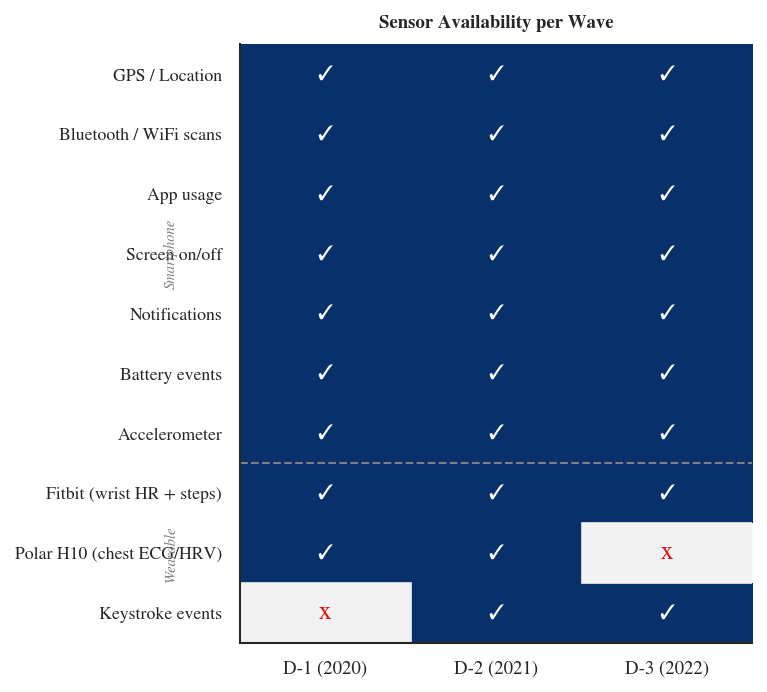

In [4]:
# Sensor names (rows) — ordered from smartphone sensors to wearables
SENSORS = [
    "GPS / Location",
    "Bluetooth / WiFi scans",
    "App usage",
    "Screen on/off",
    "Notifications",
    "Battery events",
    "Accelerometer",
    "Fitbit (wrist HR + steps)",
    "Polar H10 (chest ECG/HRV)",
    "Keystroke events",
]

# Availability matrix: rows = sensors, cols = [D-1, D-2, D-3]
# Source: paper specifications (1.0 = available, 0.0 = not available)
AVAILABILITY = np.array([
    [1.0, 1.0, 1.0],   # GPS / Location
    [1.0, 1.0, 1.0],   # Bluetooth / WiFi
    [1.0, 1.0, 1.0],   # App usage
    [1.0, 1.0, 1.0],   # Screen on/off
    [1.0, 1.0, 1.0],   # Notifications
    [1.0, 1.0, 1.0],   # Battery events
    [1.0, 1.0, 1.0],   # Accelerometer
    [1.0, 1.0, 1.0],   # Fitbit
    [1.0, 1.0, 0.0],   # Polar H10 — removed in D-3
    [0.0, 1.0, 1.0],   # Keystroke — added in D-2
])

fig, ax = plt.subplots(figsize=(5.0, 4.5), constrained_layout=True)
ax.imshow(AVAILABILITY, cmap="Blues", vmin=0, vmax=1, aspect="auto")

# Overlay availability annotations (+ = present, x = absent)
for i in range(AVAILABILITY.shape[0]):
    for j in range(AVAILABILITY.shape[1]):
        if AVAILABILITY[i, j] == 0.0:
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   color="#f2f2f2", zorder=2))
            ax.text(j, i, "x", ha="center", va="center",
                    fontsize=12, color="#E90B0B", zorder=3)
        else:
            ax.text(j, i, r"$\checkmark$", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold",
                    zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(WAVE_LABELS, fontsize=9)
ax.set_yticks(range(len(SENSORS)))
ax.set_yticklabels(SENSORS, fontsize=8.5)

# Divider between smartphone and wearable groups
ax.axhline(6.5, color="gray", lw=1, ls="--")

# Side category labels
ax.text(-0.9, 3.0, "Smartphone", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")
ax.text(-0.9, 8.0, "Wearable", ha="center", va="center",
        fontsize=7, color="gray", rotation=90, style="italic")

ax.set_title("Sensor Availability per Wave", fontweight="bold", fontsize=9, pad=8)
plt.show()

### Sensor modality matrix

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


/tmp/ipykernel_1925667/4011985652.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Blues", 2)


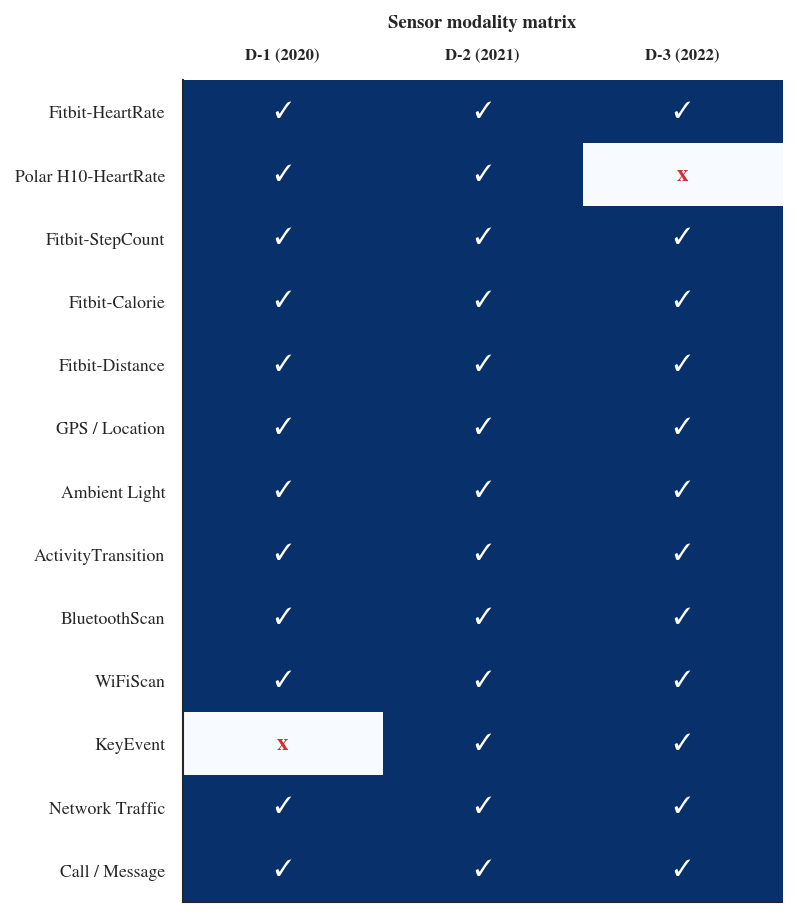

In [5]:
SENSORS_MATRIX = [
    "Fitbit-HeartRate",
    "Polar H10-HeartRate",
    "Fitbit-StepCount",
    "Fitbit-Calorie",
    "Fitbit-Distance",
    "GPS / Location",
    "Ambient Light",
    "ActivityTransition",
    "BluetoothScan",
    "WiFiScan",
    "KeyEvent",
    "Network Traffic",
    "Call / Message",
]

PRESENCE = {
    "Fitbit-HeartRate":      [1, 1, 1],
    "Polar H10-HeartRate":   [1, 1, 0],
    "Fitbit-StepCount":      [1, 1, 1],
    "Fitbit-Calorie":        [1, 1, 1],
    "Fitbit-Distance":       [1, 1, 1],
    "GPS / Location":        [1, 1, 1],
    "Ambient Light":         [1, 1, 1],
    "ActivityTransition":    [1, 1, 1],
    "BluetoothScan":         [1, 1, 1],
    "WiFiScan":              [1, 1, 1],
    "KeyEvent":              [0, 1, 1],
    "Network Traffic":       [1, 1, 1],
    "Call / Message":        [1, 1, 1],
}

mat = np.array([PRESENCE[s] for s in SENSORS_MATRIX])

fig, ax = plt.subplots(figsize=(5.2, 6.0), constrained_layout=True)
cmap = plt.cm.get_cmap("Blues", 2)
ax.imshow(mat, cmap=cmap, aspect="auto", vmin=0, vmax=1)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(WAVE_LABELS, fontweight="bold")
ax.set_yticks(range(len(SENSORS_MATRIX)))
ax.set_yticklabels(SENSORS_MATRIX, fontsize=8.5)
ax.xaxis.set_tick_params(labeltop=True, labelbottom=False)

for r in range(len(SENSORS_MATRIX)):
    for c in range(3):
        sym =  r"$\checkmark$" if mat[r, c] else "x"
        col = "white" if mat[r, c] else "#CC3333"
        ax.text(c, r, sym, ha="center", va="center",
                fontsize=11, color=col, fontweight="bold")

polar_row = SENSORS_MATRIX.index("Polar H10-HeartRate")
# ax.add_patch(plt.Rectangle((-0.5, polar_row - 0.5), 3, 1,
#              fill=False, edgecolor="#E65100", linewidth=2.5))
ax.set_title("Sensor modality matrix", fontweight="bold", fontsize=9, pad=10)
plt.show()


### Sensor and Questionnaire Coverage by Category

This matrix-style view summarizes modality availability and granularity by category across waves.


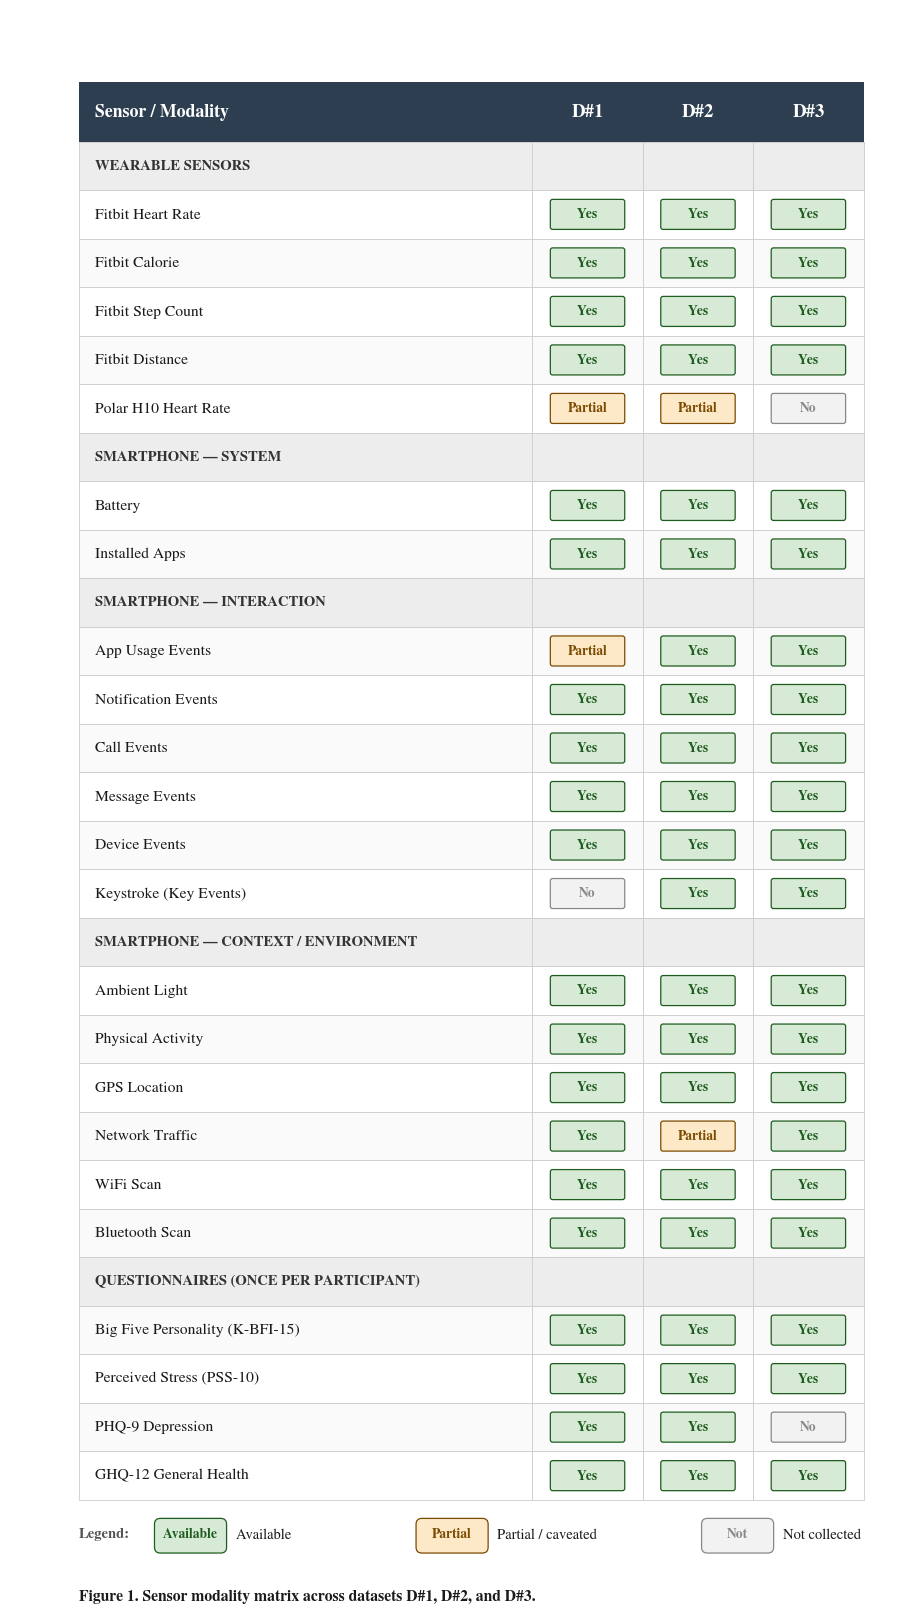

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
categories = {
    "Wearable Sensors": [
        ("Fitbit Heart Rate",          [1, 1, 1]),
        ("Fitbit Calorie",             [1, 1, 1]),
        ("Fitbit Step Count",          [1, 1, 1]),
        ("Fitbit Distance",            [1, 1, 1]),
        ("Polar H10 Heart Rate",       [2, 2, 0]),
    ],
    "Smartphone — System": [
        ("Battery",                    [1, 1, 1]),
        ("Installed Apps",             [1, 1, 1]),
    ],
    "Smartphone — Interaction": [
        ("App Usage Events",           [2, 1, 1]),
        ("Notification Events",        [1, 1, 1]),
        ("Call Events",                [1, 1, 1]),
        ("Message Events",             [1, 1, 1]),
        ("Device Events",              [1, 1, 1]),
        ("Keystroke (Key Events)",     [0, 1, 1]),
    ],
    "Smartphone — Context / Environment": [
        ("Ambient Light",              [1, 1, 1]),
        ("Physical Activity",          [1, 1, 1]),
        ("GPS Location",               [1, 1, 1]),
        ("Network Traffic",            [1, 2, 1]),
        ("WiFi Scan",                  [1, 1, 1]),
        ("Bluetooth Scan",             [1, 1, 1]),
    ],
    "Questionnaires (Once per Participant)": [
        ("Big Five Personality (K-BFI-15)", [1, 1, 1]),
        ("Perceived Stress (PSS-10)",  [1, 1, 1]),
        ("PHQ-9 Depression",           [1, 1, 0]),
        ("GHQ-12 General Health",      [1, 1, 1]),
    ],
}
footnotes = [
    "* Polar H10 worn only during assigned sub-periods per participant group (not the full collection duration).",
    "† App usage in D#1 excluded from modeling analysis due to timestamp collection errors.",
    "‡ Network traffic in D#2 excluded due to data collection application malfunction.",
]
# ── Layout ────────────────────────────────────────────────────────────────────
rows = []
for cat, sensors in categories.items():
    rows.append((cat, None, True))
    for label, vals in sensors:
        rows.append((label, vals, False))
n_rows = len(rows)
n_cols = 3
datasets = ["D#1", "D#2", "D#3"]
# ── Colors ────────────────────────────────────────────────────────────────────
COL_YES      = "#D6EAD6"
COL_YES_TXT  = "#1F5C1F"
COL_PART     = "#FDE8C8"
COL_PART_TXT = "#7A4B00"
COL_NO       = "#F2F2F2"
COL_NO_TXT   = "#888888"
COL_CAT_BG   = "#EDEDED"
COL_CAT_TXT  = "#333333"
COL_HEADER   = "#2C3E50"
COL_GRID     = "#CCCCCC"
TEXT_PRIMARY = "#1A1A1A"
TEXT_SECOND  = "#555555"
CELL_H    = 0.42
LABEL_W   = 3.9
DS_W      = 0.95
LEFT_PAD  = 0.55
RIGHT_PAD = 0.35
TOP_PAD   = 1.1
BOT_PAD   = 0.9
fig_w = LEFT_PAD + LABEL_W + n_cols * DS_W + RIGHT_PAD
fig_h = TOP_PAD + n_rows * CELL_H + BOT_PAD
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, fig_w)
ax.set_ylim(0, fig_h)
ax.axis("off")
def row_y(i):
    return fig_h - TOP_PAD - i * CELL_H
col_x = [LEFT_PAD + LABEL_W + DS_W * (j + 0.5) for j in range(n_cols)]
label_x_left = LEFT_PAD + 0.14
# ── Header ────────────────────────────────────────────────────────────────────
header_y = fig_h - TOP_PAD
header_h = 0.52
ax.add_patch(plt.Rectangle(
    (LEFT_PAD, header_y), LABEL_W + n_cols * DS_W, header_h,
    fc=COL_HEADER, ec="none", zorder=2
))
ax.text(label_x_left, header_y + header_h / 2, "Sensor / Modality",
        ha="left", va="center", fontsize=8.5, fontweight="bold",
        color="white", zorder=3)
for j, ds in enumerate(datasets):
    ax.text(col_x[j], header_y + header_h / 2, ds,
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="white", zorder=3)
# ── Rows ──────────────────────────────────────────────────────────────────────
for i, (label, vals, is_header) in enumerate(rows):
    y = row_y(i)
    if is_header:
        ax.add_patch(plt.Rectangle(
            (LEFT_PAD, y - CELL_H), LABEL_W + n_cols * DS_W, CELL_H,
            fc=COL_CAT_BG, ec=COL_GRID, linewidth=0.4, zorder=2
        ))
        ax.text(label_x_left, y - CELL_H / 2, label.upper(),
                ha="left", va="center", fontsize=7, fontweight="bold",
                color=COL_CAT_TXT, zorder=3)
        for j in range(n_cols):
            ax.add_patch(plt.Rectangle(
                (LEFT_PAD + LABEL_W + j * DS_W, y - CELL_H), DS_W, CELL_H,
                fc=COL_CAT_BG, ec=COL_GRID, linewidth=0.4, zorder=2
            ))
    else:
        stripe = "#FAFAFA" if (i % 2 == 0) else "#FFFFFF"
        ax.add_patch(plt.Rectangle(
            (LEFT_PAD, y - CELL_H), LABEL_W, CELL_H,
            fc=stripe, ec=COL_GRID, linewidth=0.4, zorder=2
        ))
        ax.text(label_x_left, y - CELL_H / 2, label,
                ha="left", va="center", fontsize=7.5,
                color=TEXT_PRIMARY, zorder=3)
        for j, v in enumerate(vals):
            cx = LEFT_PAD + LABEL_W + j * DS_W
            ax.add_patch(plt.Rectangle(
                (cx, y - CELL_H), DS_W, CELL_H,
                fc=stripe, ec=COL_GRID, linewidth=0.4, zorder=2
            ))
            if v == 1:
                chip_fc, chip_tc, chip_txt = COL_YES,  COL_YES_TXT,  "Yes"
            elif v == 2:
                chip_fc, chip_tc, chip_txt = COL_PART, COL_PART_TXT, "Partial"
            else:
                chip_fc, chip_tc, chip_txt = COL_NO,   COL_NO_TXT,   "No"
            chip_w, chip_h = 0.60, 0.22
            chip_rx = cx + (DS_W - chip_w) / 2
            chip_ry = y - CELL_H / 2 - chip_h / 2
            ax.add_patch(FancyBboxPatch(
                (chip_rx, chip_ry), chip_w, chip_h,
                boxstyle="round,pad=0.02",
                fc=chip_fc, ec=chip_tc, linewidth=0.6, zorder=3
            ))
            ax.text(chip_rx + chip_w / 2, chip_ry + chip_h / 2, chip_txt,
                    ha="center", va="center", fontsize=6.5,
                    fontweight="bold", color=chip_tc, zorder=4)
# ── Legend ────────────────────────────────────────────────────────────────────
leg_y = row_y(n_rows - 1) - CELL_H - 0.32
chips = [
    (COL_YES,  COL_YES_TXT,  "Available"),
    (COL_PART, COL_PART_TXT, "Partial / caveated"),
    (COL_NO,   COL_NO_TXT,   "Not collected"),
]
lx = LEFT_PAD
ax.text(lx, leg_y + 0.02, "Legend:", fontsize=7, color=TEXT_SECOND,
        va="center", fontweight="bold")
lx += 0.7
for fc, tc, lbl in chips:
    ax.add_patch(FancyBboxPatch(
        (lx, leg_y - 0.09), 0.52, 0.20,
        boxstyle="round,pad=0.05",
        fc=fc, ec=tc, linewidth=0.6, zorder=3
    ))
    ax.text(lx + 0.26, leg_y + 0.02, lbl.split(" ")[0],
            ha="center", va="center", fontsize=6.5,
            fontweight="bold", color=tc, zorder=4)
    lx += 0.65
    ax.text(lx, leg_y + 0.02, lbl, fontsize=7, color=TEXT_PRIMARY, va="center")
    lx += max(len(lbl) * 0.067, 1.0)
    lx+=0.6
# ── Footnotes ─────────────────────────────────────────────────────────────────
# fn_y = leg_y - 0.32
# for fn in footnotes:
#     ax.text(LEFT_PAD, fn_y, fn, fontsize=6.2, color=TEXT_SECOND,
#             va="top", style="italic")
#     fn_y -= 0.20
# ── Caption ───────────────────────────────────────────────────────────────────
cap_y = (leg_y - 0.32) - 0.14
ax.text(LEFT_PAD, cap_y,
        "Figure 1. Sensor modality matrix across datasets D#1, D#2, and D#3.",
        fontsize=7.5, color=TEXT_PRIMARY, va="top", fontweight="bold")
plt.show()